# `c05uf001` &mdash; the Rankine cycle of Illustration 5.2-1

Illustration 5.2-1 works a Rankine power cycle and draws it on the temperature&ndash;entropy
diagram for steam. That drawing is **`c05uf001`**, an unnumbered in-illustration figure, and
this notebook produces it.

The chart underneath is **Figure 3.3-1(b)**, built from the book's own **Appendix A.III** &mdash;
digitized to CSV in `code/data/` and wrapped by `thermo.steam_chart`. So this notebook is only
the *cycle* and the numbers that go with it; redraw Fig. 3.3-1(b) and this figure follows.

**The cycle.** Saturated liquid water at 100&nbsp;°C is pumped to 3.0&nbsp;MPa, heated and
boiled to 600&nbsp;°C, expanded through a reversible adiabatic turbine back to the condenser
pressure, and condensed. Pump and turbine are both reversible.

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when the thermo package is already alongside this notebook (the normal
# case: you cloned the repository and are running from code/ch5/). In Colab there
# is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
else:
    sys.path.insert(0, '..')
# ---------------------------------------------------------------------------

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import PchipInterpolator

from thermo.charts import use_book_style
from thermo.steam_chart import SteamTables, temperature_entropy

use_book_style()          # Computer Modern, with real TeX if it is installed

st = SteamTables()        # Appendix A.III, digitized
sat, cl = st.sat, st.cl

## 1. The four states

⚠️ **Two of the illustration's printed temperatures are wrong, and the illustration prints the
numbers that contradict them on the facing page.** Both are the ones the 5e flags with a tilde
as *"obtained from the steam tables by interpolation"*:

| point | 5e table | correct | the 5e's **own Aspen output** |
|---|---|---|---|
| 2, pump exit | ~103 °C | **100.20 °C** | 100.2 |
| 4, turbine exit | ~126.2 °C | **129.45 °C** | 129.6 |

The pump's entire temperature rise is **0.2 K** &mdash; liquid water is nearly incompressible,
so 2.9&nbsp;MPa of lift barely warms it &mdash; and ~103 is not close. Point 4's *enthalpy* is
right (2734.7 against 2734.83), so that interpolation went wrong in temperature only.

Everything else in the printed table reproduces, **including the 29.0 % efficiency**, which is
the strongest check that the figure and the illustration agree.

In [3]:
P_LO, P_HI, T_MAX, T1 = 0.10135, 3.0, 600.0, 100.0
row = sat.loc[np.isclose(sat.T_C, T1)].iloc[0]
S1, H1, V1 = float(row.Sl), float(row.Hl), float(row.Vl)
W_pump = V1*(P_HI - P_LO)*1e3                   # m3/kg x MPa -> kJ/kg
H2, S2 = H1 + W_pump, S1

# Point 2's temperature. A.III's compressed-liquid table starts at 5 MPa, so read the
# isentropic rise there and scale it: liquid is near enough incompressible that the
# rise is linear in pressure. It comes to 0.2 K.
_cl5 = cl[np.isclose(cl.P_MPa, 5.0)].dropna(subset=["S", "T_C"]).sort_values("T_C")
T2 = T1 + (float(PchipInterpolator(_cl5.S.values, _cl5.T_C.values)(S1)) - T1) \
     * (P_HI - P_LO)/(5.0 - P_LO)

S_hi, H_hi, T_hi = st.isobar(P_HI)
S3 = float(PchipInterpolator(T_hi, S_hi)(T_MAX))
H3 = float(PchipInterpolator(T_hi, H_hi)(T_MAX))

# Point 4 sits at 0.10135 MPa, the saturation pressure at 100 C; A.III tabulates 0.1
# and 0.2. Interpolating between the two isobars is worth it -- on 0.1 alone T4 comes
# out a degree low.
def _state_at(P, S):
    Sx, Hx, Tx = st.isobar(P)
    return (float(PchipInterpolator(Sx, Tx)(S)), float(PchipInterpolator(Sx, Hx)(S)))


(T_a, H_a), (T_b, H_b) = _state_at(0.1, S3), _state_at(0.2, S3)
f = (P_LO - 0.1)/(0.2 - 0.1)
T4, H4 = T_a + f*(T_b - T_a), H_a + f*(H_b - H_a)
eta = -((H4 - H3) + W_pump)/(H3 - H2)

print(f"{'point':<6}{'T (C)':>9}{'P (MPa)':>10}{'S':>10}{'H':>10}    the 5e table")
for n, (T, P, S, H, ref) in enumerate((
        (T1, P_LO, S1, H1, "100      1.3069   419.04"),
        (T2, P_HI, S2, H2, "~103     1.3069   422.07   <-- wrong"),
        (T_MAX, P_HI, S3, H3, "600      7.5085  3682.3"),
        (T4, P_LO, S3, H4, "~126.2   7.5085  ~2734.7   <-- wrong")), 1):
    print(f"{n:<6}{T:9.2f}{P:10.5f}{S:10.4f}{H:10.2f}    {ref}")
print(f"\nW_pump {W_pump:6.2f} [5e 3.03]     W_turbine {H4-H3:8.1f} [5e -947.6]")
print(f"Q_boiler {H3-H2:6.1f} [5e 3260.2]  Q_condenser {H1-H4:8.1f} [5e -2315.7]")
print(f"efficiency {eta:.4f} = {100*eta:.1f} %                 [5e 0.290 = 29.0 %]")

point     T (C)   P (MPa)         S         H    the 5e table
1        100.00   0.10135    1.3069    419.04    100      1.3069   419.04
2        100.20   3.00000    1.3069    422.07    ~103     1.3069   422.07   <-- wrong
3        600.00   3.00000    7.5085   3682.30    600      7.5085  3682.3
4        129.45   0.10135    7.5085   2734.83    ~126.2   7.5085  ~2734.7   <-- wrong

W_pump   3.03 [5e 3.03]     W_turbine   -947.5 [5e -947.6]
Q_boiler 3260.2 [5e 3260.2]  Q_condenser  -2315.8 [5e -2315.7]
efficiency 0.2897 = 29.0 %                 [5e 0.290 = 29.0 %]


## 2. The figure

⚠️ **Points 1 and 2 are one pixel apart on an 800-degree axis** &mdash; that *is* the pump's
whole temperature rise. They are marked where they really are and their labels led away, rather
than drawn apart to imply a gap that is not there.

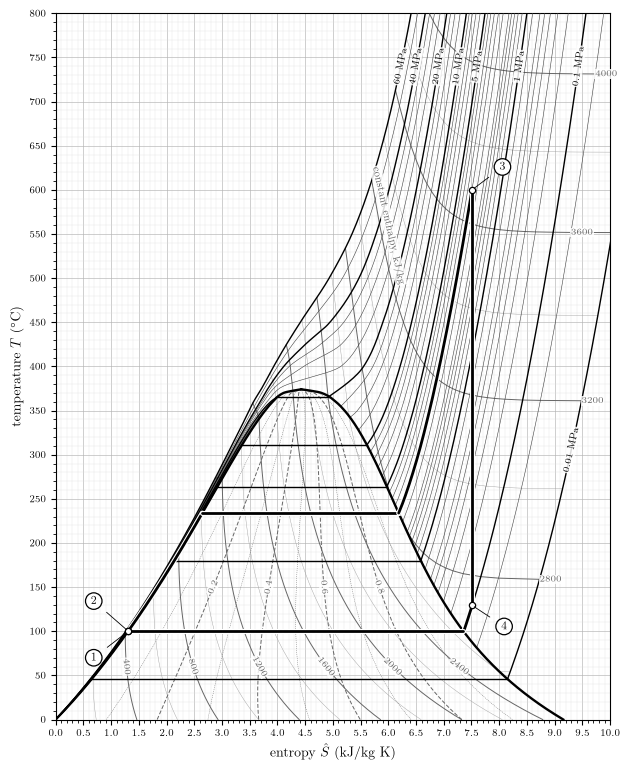

In [4]:
# ART SLOT c05uf001 -- unnumbered in-illustration art, 6.4 x 7.8 in.
Ts = float(st.Tsat_of_P(P_HI))
dome = st.dome
Sl_s, Sv_s = float(dome["Sl"](Ts)), float(dome["Sv"](Ts))
Sv_lo = float(dome["Sv"](T1))
Tliq = np.linspace(T2, Ts, 200)      # 3 MPa compressed liquid sits within 0.005
Sliq = dome["Sl"](Tliq)              # kJ/(kg K) of the saturated-liquid line here
m_sh = (T_hi >= Ts) & (T_hi <= T_MAX)
S_lo, H_lo, T_lo = st.isobar(0.1)
m_lo = (T_lo >= T1) & (T_lo <= T4)
segs = [(np.array([S1, S2]), np.array([T1, T2])),
        (Sliq, Tliq),
        (np.array([Sl_s, Sv_s]), np.array([Ts, Ts])),
        (np.r_[Sv_s, S_hi[m_sh], S3], np.r_[Ts, T_hi[m_sh], T_MAX]),
        (np.array([S3, S3]), np.array([T_MAX, T4])),
        (np.r_[S3, S_lo[m_lo][::-1], Sv_lo], np.r_[T4, T_lo[m_lo][::-1], T1]),
        (np.array([Sv_lo, S1]), np.array([T1, T1]))]

fig, ax = plt.subplots(figsize=(6.4, 7.8))
temperature_entropy(ax, st)
HALO = [pe.withStroke(linewidth=3.6, foreground="white")]
for S, T in segs:
    ax.plot(S, T, "-", color="k", lw=2.0, zorder=7, path_effects=HALO,
            solid_capstyle="round", solid_joinstyle="round")


def state(lab, S, T, dS, dT):
    """Mark a state where it really is and lead the label away from it."""
    ax.plot([S], [T], "o", mfc="white", mec="k", mew=0.9, ms=4.5, zorder=8)
    ax.annotate(lab, xy=(S, T), xytext=(S + dS, T + dT), fontsize=8, ha="center",
                va="center", zorder=9,
                bbox=dict(boxstyle="circle,pad=0.30", fc="white", ec="k", lw=0.9),
                arrowprops=dict(arrowstyle="-", lw=0.6, shrinkA=6, shrinkB=2))


state("1", S1, T1, -0.62, -30)
state("2", S2, T2, -0.62, 34)
state("3", S3, T_MAX, 0.55, 26)
state("4", S3, T4, 0.58, -24)
fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/c05uf001.pdf")                 # the printed figure
plt.show()

## What this notebook shows

- **`c05uf001`**, the Rankine cycle of Illustration 5.2-1 drawn on the steam
  $T$&ndash;$\hat S$ chart, with all four states computed from Appendix A.III.
- **Every number in the printed table reproduces**, including the 29.0 % efficiency &mdash;
  which is the check that the chart and the illustration agree.
- ⚠️ **Except the two interpolated temperatures**, which are 5e errata: point 2 is
  100.2&nbsp;°C, not ~103, and point 4 is 129.5&nbsp;°C, not ~126.2. The illustration's own
  Aspen output on the facing page already said so.

## Your turn

- Raise the boiler pressure from 3&nbsp;MPa and watch the efficiency climb &mdash; and watch
  point 4 move *into* the dome. At what pressure does the turbine start producing wet steam,
  and why is that a problem for a real turbine?
- Superheat further than 600&nbsp;°C: how much efficiency does each extra 100&nbsp;°C buy?
- Add a reheat stage between two turbines and redraw the cycle.